# Previewable mutations: fix bad ticks without fearing the delete key

Deleting or rewriting rows in a shared tick store is the scariest routine
operation on a quant desk. A fat-fingered `DELETE WHERE` has ruined more
research datasets than any hardware failure.

h5i-db's answer is the **plan/apply flow**. A mutation is first staged as a
plan carrying a machine-readable summary and before/after row samples. You
review it, and only then apply it, as a new version with the old one intact.

In this recipe we:

1. inject two classic tick-data pathologies, a feed glitch and a 10x scaling
   bug, and find them with SQL,
2. stage a delete, catch ourselves over-deleting in the preview, discard, and
   re-plan narrower before applying,
3. stage a `replace_range` that repairs prices in place,
4. lock the database down with a mutation policy, so direct destructive writes
   raise `PolicyError`.

That last step is the safety story for shared and agent-operated databases.

In [1]:
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, sql_expr, time_bucket
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("00_mutations"), create=True)

## 1. The data

Two sessions of ticks from `cu.make_trades`, one row per print.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | trade timestamp, ascending |
| `symbol` | `string` | ticker |
| `price` | `float64` | trade price |
| `size` | `int64` | shares traded |
| `exchange` | `string` | reporting venue |
| `side` | `string` | `B` buyer-initiated, `S` seller-initiated |

In [2]:
trades = cu.make_trades(symbols=["AAPL", "MSFT", "NVDA"], days=2, trades_per_day=20_000, seed=7)
print(f"{trades.num_rows:,} rows x {trades.num_columns} columns")
trades.to_pandas().head()

118,219 rows x 6 columns


,ts,symbol,price,size,exchange,side
0,2026-06-01 13:30:00.669981+00:00,AAPL,265.05,1,ARCA,B
1,2026-06-01 13:30:00.865263+00:00,MSFT,362.97,1,IEX,S
2,2026-06-01 13:30:01.023598+00:00,NVDA,319.28,1,IEX,B
3,2026-06-01 13:30:01.117852+00:00,AAPL,265.01,1,BATS,S
4,2026-06-01 13:30:01.135445+00:00,MSFT,362.97,100,IEX,S


## 2. Inject two pathologies

We corrupt that clean feed the way real feeds break.

- **Feed glitch.** For ten seconds on day 1 (15:00:00–15:00:10 UTC) every
  print, in every symbol, arrives at 10x. A decimal-shift burst.
- **Scaling bug.** For ten minutes on day 2 (14:00–14:10 UTC) one symbol's
  prices are all 10x. A per-symbol multiplier bug in a feed handler.

The two need different treatment. Glitch rows are garbage, so delete them.
Scaling-bug rows are real trades with a recoverable price, so repair them.

In [3]:
df = trades.to_pandas()

glitch = (df["ts"] >= "2026-06-01 15:00:00+00:00") & (df["ts"] < "2026-06-01 15:00:10+00:00")
scaling = (
    (df["ts"] >= "2026-06-02 14:00:00+00:00")
    & (df["ts"] < "2026-06-02 14:10:00+00:00")
    & (df["symbol"] == "MSFT")
)
df.loc[glitch | scaling, "price"] *= 10.0
corrupted = pa.Table.from_pandas(df, schema=trades.schema, preserve_index=False)

db.create_table("trades", trades.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("trades", corrupted, note="raw feed capture, days 1-2")
print(f"{glitch.sum()} glitch prints, {scaling.sum()} scaled prints, {len(df):,} rows total")

18 glitch prints, 1502 scaled prints, 118,219 rows total


## 3. Find the damage

A robust screen compares every print to its symbol's daily median, via
`approx_percentile_cont`. The corrupt rows sit at roughly 10x their median,
while the median itself barely moves because the corrupt fraction is small.
This is why medians, not means, anchor outlier screens.

We run this detector twice, now and again after the repair, so it is written
once as a function of the read point. The `trades` frame feeds both sides of
its own join: once grouped into daily medians, once as the row-level left
side.

In [4]:
DAY = time_bucket("1d", col("ts"))


def outliers(version=None):
    src = db.table("trades", version=version)
    med = src.group_by("symbol", DAY.alias("day")).agg(
        med_px=sql_expr("approx_percentile_cont(price, 0.5)")
    )
    return (
        src.with_columns(day=DAY)
        .join(med, on=["symbol", "day"])
        .filter(col("price", relation="l") > 3 * col("med_px", relation="r"))
        .select(
            ts=col("ts", relation="l"),
            symbol=col("symbol", relation="l"),
            price=col("price", relation="l"),
            x_median=col("price", relation="l") / col("med_px", relation="r"),
        )
        .sort("ts")
    )


flagged = outliers().to_pandas()
flagged.groupby([flagged["ts"].dt.floor("1D").rename("day"), "symbol"]).size()

day                        symbol
2026-06-01 00:00:00+00:00  AAPL         6
                           MSFT         9
                           NVDA         3
2026-06-02 00:00:00+00:00  MSFT      1502
dtype: int64

Two clusters, exactly as injected: an all-symbol burst on day 1 and an
MSFT-only stretch on day 2. Now derive the time bounds of each from the
flagged rows.

**Mutation-plan ranges are raw int64 microseconds**, matching the unit of the
`ts` column, and they are half-open `[start, end)`. So add 1µs past the last
bad print.

In [5]:
burst = flagged[flagged["ts"] < "2026-06-02"]
bug = flagged[(flagged["ts"] >= "2026-06-02") & (flagged["symbol"] == "MSFT")]

burst_lo = int(burst["ts"].min().value // 1000)
burst_hi = int(burst["ts"].max().value // 1000) + 1
bug_lo = int(bug["ts"].min().value // 1000)
bug_hi = int(bug["ts"].max().value // 1000) + 1
print("burst window:", burst["ts"].min(), "->", burst["ts"].max())
print("bug   window:", bug["ts"].min(), "->", bug["ts"].max())

burst window: 2026-06-01 15:00:00.057277+00:00 -> 2026-06-01 15:00:09.919403+00:00
bug   window: 2026-06-02 14:00:00.344957+00:00 -> 2026-06-02 14:09:59.689919+00:00


## 4. Stage a delete, and catch the over-delete before it happens

First instinct: nuke the whole five minutes around the glitch, to be safe.
Stage it and look at the plan before believing it. A plan is not a commit, so
nothing in the table has changed yet.

One property of range mutations matters more than any other here. **The range
is on time only** and does not filter by symbol. A "safe, wide" window
silently takes healthy AAPL and NVDA prints with it. The plan summary makes
that visible before any damage is done.

In [6]:
sloppy = db.plan_delete_range(
    "trades",
    int(pd.Timestamp("2026-06-01 15:00:00", tz="UTC").value // 1000),
    int(pd.Timestamp("2026-06-01 15:05:00", tz="UTC").value // 1000),
    note="delete glitch burst (wide window)",
)
sloppy.summary

{'rows_before': 118219,
 'rows_after': 117737,
 'rows_affected': 482,
 'segments_reused': 0,
 'segments_added': 1,
 'added_bytes': 879306,
 'affected_time_range': [1780326000000000, 1780326300000000]}

`rows_affected` is about 25x the number of bad prints, so the wide window
would destroy hundreds of good trades. `before_sample` shows the doomed rows:
healthy \\$200-ish prints mixed in with the 10x garbage.

Discard, then re-plan on the tight bounds the detector gave us.

In [7]:
sloppy.before_sample.to_pandas().head(6)

,ts,symbol,price,size,exchange,side
0,2026-06-01 15:00:00.057277+00:00,MSFT,3591.4,1,BATS,B
1,2026-06-01 15:00:00.862948+00:00,AAPL,2664.0,1,IEX,S
2,2026-06-01 15:00:01.169986+00:00,MSFT,3591.8,1,IEX,B
3,2026-06-01 15:00:01.410323+00:00,MSFT,3591.4,1,ARCA,S
4,2026-06-01 15:00:01.654483+00:00,NVDA,3181.7,100,ARCA,B
5,2026-06-01 15:00:01.980758+00:00,MSFT,3591.9,400,NASDAQ,B


In [8]:
sloppy.discard()

tight = db.plan_delete_range("trades", burst_lo, burst_hi, note="delete 10s decimal-shift burst")
print("rows_affected:", tight.summary["rows_affected"], " (bad prints:", len(burst), ")")
commit = tight.apply()
print("applied as version", commit["sequence"], "op:", commit["op"])

rows_affected: 18  (bad prints: 18 )
applied as version 2 op: delete_range


`apply()` re-checks the table head first. If anyone committed after the plan
was staged, it raises `ConflictError` rather than publishing a mutation
computed against a stale base. That is the same optimistic concurrency as
`append(expected_version=...)`.

## 5. Repair in place with `plan_replace_range`

The MSFT scaling bug needs the other treatment. The trades are real and the
prices are recoverable by dividing by 10.

`plan_replace_range(start, end, data)` swaps *everything* in the window for
the data you provide. The replacement must therefore contain the window's AAPL
and NVDA rows unchanged, alongside the repaired MSFT rows.

In [9]:
win = df[(df["ts"] >= pd.Timestamp(bug_lo, unit="us", tz="UTC"))
         & (df["ts"] < pd.Timestamp(bug_hi, unit="us", tz="UTC"))].copy()
win.loc[win["symbol"] == "MSFT", "price"] /= 10.0
repaired = pa.Table.from_pandas(win, schema=trades.schema, preserve_index=False)

fix = db.plan_replace_range("trades", bug_lo, bug_hi, data=repaired,
                            note="MSFT 10x scaling bug: prices /10")
fix.summary

{'rows_before': 118201,
 'rows_after': 118201,
 'rows_affected': 4179,
 'segments_reused': 0,
 'segments_added': 1,
 'added_bytes': 879593,
 'affected_time_range': [1780408800344957, 1780409399689920]}

In [10]:
# after_sample previews the post-mutation rows - MSFT back at sane levels:
fix.after_sample.to_pandas().query("symbol == 'MSFT'").head(4)

,ts,symbol,price,size,exchange,side
0,2026-06-02 14:00:00.344957+00:00,MSFT,355.32,100,IEX,B
4,2026-06-02 14:00:00.688344+00:00,MSFT,355.34,1,NYSE,B
7,2026-06-02 14:00:01.093424+00:00,MSFT,355.26,1,BATS,S


In [11]:
fix.apply()
assert len(outliers().collect()) == 0
print("detector re-run: 0 outliers remaining")

detector re-run: 0 outliers remaining


Every correction is a version. The uncorrected capture stays one integer away,
so "did the cleaning change my backtest?" is a SQL join rather than an
archaeology project. Recipe 05 covers that comparison.

In [12]:
pd.DataFrame(db.versions("trades"))[["sequence", "op", "rows", "note"]]

,sequence,op,rows,note
0,0,create,0,NaN
1,1,append,118219,"raw feed capture, days 1-2"
2,2,delete_range,118201,delete 10s decimal-shift burst
3,3,replace_range,118201,MSFT 10x scaling bug: prices /10


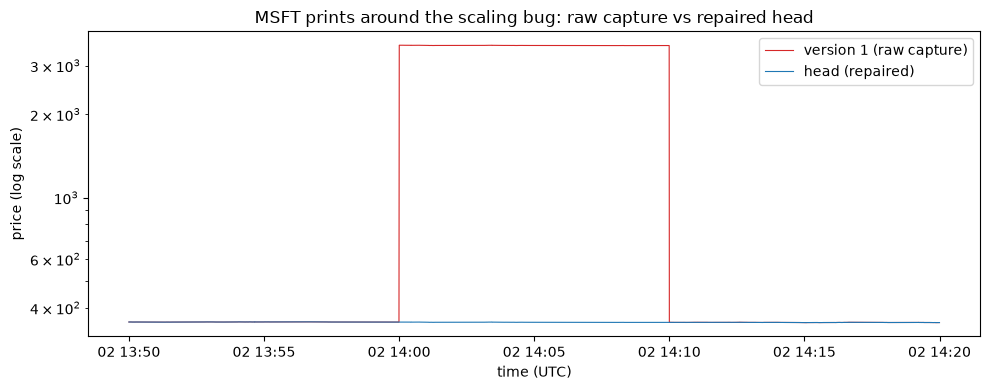

In [13]:
import matplotlib.pyplot as plt

def msft_window(version=None):
    return (
        db.table("trades", version=version)
        .filter(
            col("symbol") == "MSFT",
            col("ts") >= "2026-06-02T13:50:00Z",
            col("ts") < "2026-06-02T14:20:00Z",
        )
        .select("ts", "price")
        .sort("ts")
        .to_pandas()
    )


before, after = msft_window(version=1), msft_window()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(before["ts"], before["price"], lw=0.8, color="tab:red", label="version 1 (raw capture)")
ax.plot(after["ts"], after["price"], lw=0.8, color="tab:blue", label="head (repaired)")
ax.set_yscale("log")
ax.set_title("MSFT prints around the scaling bug: raw capture vs repaired head")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("price (log scale)")
ax.legend()
fig.tight_layout()

## 6. Mutation policy: make the safe path the only path

On a shared database, or one an automated agent writes to, you want direct
destructive operations off by default. `set_policy` flips boolean gates per
operation class, and a gated direct call raises `PolicyError` **before
touching anything**.

The plan/apply flow stays available under any policy. That is deliberate: it
*is* the sanctioned route, because it forces a previewable, reviewable
artifact between intent and mutation.

In [14]:
print("default policy:", db.policy())
db.set_policy(direct_write=False, direct_delete=False, direct_restore=False)

try:
    db.write("trades", corrupted)
except h5i_db.PolicyError as e:
    print(f"\nwrite blocked -> {type(e).__name__}")
    print("  code:", e.code)
    print("  hint:", e.hint)

default policy: {'direct_append': True, 'direct_write': True, 'direct_replace': True, 'direct_delete': True, 'direct_restore': True, 'direct_compact': True}

write blocked -> PolicyError
  code: policy_violation
  hint: run the write with --plan to preview it, review, then `h5i-db plan apply`; or relax the policy with `h5i-db policy set`


Planning is still allowed under the restrictive policy. Pending plans are
first-class objects: `list_plans` shows what is staged and with which summary.
Plans expire after a 7-day TTL, and their staged segments are protected from
`vacuum` until they are applied, discarded or expired.

In [15]:
pending = db.plan_delete_range(
    "trades",
    int(pd.Timestamp("2026-06-01 16:00:00", tz="UTC").value // 1000),
    int(pd.Timestamp("2026-06-01 16:00:30", tz="UTC").value // 1000),
    note="staged under restrictive policy",
)

for p in db.list_plans("trades"):
    ttl_days = (p.raw["expires_at_ns"] - p.raw["created_at_ns"]) / 86_400e9
    print(f"plan {p.plan_id[:8]}…  note={p.raw['note']!r}  "
          f"rows_affected={p.summary['rows_affected']}  ttl={ttl_days:.0f}d")

pending.discard()
db.set_policy(direct_write=True, direct_delete=True, direct_restore=True)

plan cbc00464…  note='staged under restrictive policy'  rows_affected=30  ttl=7d


{'direct_append': True,
 'direct_write': True,
 'direct_replace': True,
 'direct_delete': True,
 'direct_restore': True,
 'direct_compact': True}

## Takeaways

- **Plan, look, then apply.** `plan_delete_range` and `plan_replace_range`
  stage a mutation with a row-count summary and before/after samples. The
  over-wide delete announced itself in `rows_affected` before it could do any
  harm.
- Mutation ranges are raw int64 microseconds, half-open, and time-only. They
  never filter by symbol, so a replacement must carry the innocent rows of the
  window through unchanged.
- `apply()` is conflict-checked against the table head. Every applied plan is
  a new version with a note, and the uncorrected data stays one
  `h5i('trades', v)` away.
- `set_policy(direct_write=False, ...)` turns "please be careful" into a
  `PolicyError`. That is the right default for shared stores, and for anything
  an LLM agent is allowed to touch.

In [16]:
db.close()